# 2D full-field sarcomere tracking

Automated tracking of every sarcomere vector across the whole image — the complement to the 1D LOI method. Results are stored as dense `(n_tracks, T)` arrays in `sarc.data`.

After tracking, you choose **how to analyse the motion** by *grouping* the tracks — `pool`, `m-band`, `myofibril`, `loi`, `domain`, or `custom` — all fed through one shared contraction engine via `group_tracks(...)` then `analyze_track_motion(...)` (see *Choosing an analysis method* below).

Details: [API reference](../autoapi/sarcasm/analysis/sarcomere_tracking/index.html).

In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from sarcasm import *
import matplotlib.pyplot as plt
import numpy as np

## Detection

Run the sarcomere U-Net on the movie (same upstream step as the structural and LOI tutorials). We also run the **3D U-Net fast-movie Z-band model** — it emits Z-band masks that are ~3× less noisy frame-to-frame than the per-frame 2D output and is used automatically by `analyze_sarcomere_vectors` when available.

In [3]:
file_path = '../../test_data/high_speed_single_ACTN2-citrine_CM/20kPa.tif'
sarc = SarcAsM(file_path, restart=False)

2026-07-29 17:05:44 - sarcasm.utils - INFO - Using device: mps


In [4]:
# sarc.detect_sarcomeres()
sarc.detect_z_bands_fast_movie()  # 3D U-Net — optional but recommended for high-speed movies (potentially re-training necessary for different imaging conditions)

2026-07-29 14:20:56 - sarcasm.analysis.detection - INFO - Predicting sarcomere z-bands ...
100%|██████████| 90/90 [01:08<00:00,  1.31it/s]


## Sarcomere vectors

`peak_algorithm='loi'` uses the same peak-detection pipeline as the LOI analysis (6× Akima + prominence 0.5 + COM refinement) — maximum per-frame slen accuracy. `smooth_orientation_sigma` applies an axial-correct temporal Gaussian to the orientation field.

`use_fast_movie_zbands=True` (the default) reads from `zbands_fast_movie.tif` when it exists. The log line printed by this cell tells you which Z-band source was used; set `use_fast_movie_zbands=False` to force the per-frame 2D masks if the 3D model is unreliable on a given movie.

In [5]:
sarc.analyze_sarcomere_vectors(
    linewidth=0.65,
    peak_algorithm='loi',
    smooth_orientation_sigma=1.5,
)

2026-07-29 14:22:30 - sarcasm.structure - INFO - Temporally smoothing orientation field with sigma=1.500 frames...
2026-07-29 14:22:35 - sarcasm.structure - INFO - Smoothing orientation field (median filter, radius=4 px) across 500 frame(s)…
100%|██████████| 500/500 [02:15<00:00,  3.70it/s]
2026-07-29 14:24:52 - sarcasm.structure - INFO - Starting sarcomere length and orientation analysis...
100%|██████████| 500/500 [04:38<00:00,  1.79it/s]


## 2D tracker
Flow-advects each sarcomere query point and snaps it to the nearest consistent detection every frame. See docstring for all parameters.

In [6]:
sarc.track_sarcomere_vectors()

2026-07-29 14:29:46 - sarcasm.structure - INFO - Tracking 500 frames...
2026-07-29 14:29:46 - sarcasm.analysis.sarcomere_tracking - INFO - Tracking horizons: memory=20 frames, max_gap_interpolation=5 frames (frametime=0.01).
2026-07-29 14:29:46 - sarcasm.analysis.sarcomere_tracking - INFO - Seeding query points from frame 0…
2026-07-29 14:29:46 - sarcasm.analysis.sarcomere_tracking - INFO - Tracking frames…
2026-07-29 14:29:58 - sarcasm.analysis.sarcomere_tracking - INFO - Merging short trajectory fragments…
2026-07-29 14:30:00 - sarcasm.analysis.sarcomere_tracking - INFO - Merge pass 1: 131 fragment pairs.
2026-07-29 14:30:00 - sarcasm.analysis.sarcomere_tracking - INFO - Merged 131 fragment pairs total.
2026-07-29 14:30:00 - sarcasm.analysis.sarcomere_tracking - INFO - Filtering short tracks…
2026-07-29 14:30:00 - sarcasm.structure - INFO - Tracked 8678 sarcomere query points over 500 frames.


## Choosing an analysis method

After tracking, every track carries its own sarcomere-length time-series `sarc.data['tracks_slen']` of shape `(n_tracks, T)`. The post-tracking analysis **methods** are just different *groupings* of those tracks, all fed through one shared contraction engine (ContractionNet):

| `by=` | grouping | typical use |
|---|---|---|
| `'pool'` | all tracks in one group | whole-cell beating |
| `'mband'` | tracks sharing an M-band | laterally-registered sarcomeres |
| `'myofibril'` | ordered fibre chains | LOI-style, per-fibre (all fibres) |
| `'loi'` | curated / hand-drawn fibre lines | LOI-style, selected fibres |
| `'domain'` | Leiden domains | replaces the former `analyze_domain_motion` |
| `'custom'` | your own labels | any partition |

The workflow is two steps — `group_tracks(by=...)` writes a cheap, inspectable label artifact, and `analyze_track_motion()` runs the per-group contraction analysis — or use the one-call front door `analyze_track_motion(by=...)`. Results are written under a `<kind>_*` prefix (e.g. `pool_beating_rate`, `mband_slen_timeseries`).

### (1) Pool level — whole-cell ensemble beating

All eligible tracks form a single group, so the result is one whole-cell signal. Zero-config and a safe first call: it needs nothing but the tracks themselves.

2026-07-29 15:51:07 - sarcasm.structure - INFO - group_tracks(by='pool'): 1 groups, 3813/8678 tracks assigned.
2026-07-29 15:51:08 - sarcasm.structure - INFO - analyze_track_motion: 1 'pool' groups...
2026-07-29 15:51:08 - sarcasm.analysis.contraction_analysis - INFO - 1/4 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.
2026-07-29 15:51:08 - sarcasm.structure - INFO - analyze_track_motion complete ('pool', 1 groups).


cell beating rate [Hz]: 0.7614213197969543
tracks assigned to the pool:           3813/8678 (44%)
sarcomere-vector obs. in a long track: 1711586/2037778 (84%)


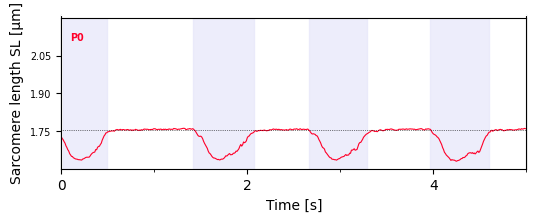

In [5]:
# zero-config, a safe first call
sarc.analyze_track_motion(by='pool')   # all tracks with coverage >= 0.5 -> one signal
print('cell beating rate [Hz]:', sarc.data['pool_beating_rate'][0])

# --- QC: how much of the detected signal actually backs that pool trace? ---
n_assigned = int((sarc.data['track_group_id'] >= 0).sum())
n_tracks   = int(sarc.data['n_tracks'])
n_vec_long = sarc.data['group_n_vectors_in_long_tracks']
n_vec_tot  = sarc.data['group_n_vectors_total']
print(f'tracks assigned to the pool:           {n_assigned}/{n_tracks} '
      f'({100 * n_assigned / n_tracks:.0f}%)')
print(f'sarcomere-vector obs. in a long track: {n_vec_long}/{n_vec_tot} '
      f'({100 * n_vec_long / n_vec_tot:.0f}%)')
# The track count is dominated by many short fragments, so it looks low; weighting by
# sarcomere-vector observations shows most of the real signal is captured by long tracks.

# whole-cell mean sarcomere length over time
fig, ax = plt.subplots(figsize=(6, 2))
Plots.plot_slen_mean(ax, sarc, kind='pool', t_lim=(0, 5))
plt.show()

### Four views of the grouped motion

The same `<kind>_*` results drive four plotting functions — two granularities × two quantities:

|  | sarcomere length (SL) | length change (ΔSL) |
|---|---|---|
| **per-group mean** (one stacked row per group) | `plot_slen_mean` | `plot_delta_slen_mean` |
| **individual sarcomeres + mean** (one group) | `plot_slen` | `plot_delta_slen` |

`plot_slen` / `plot_delta_slen` overlay every member sarcomere of one `group` (subsampled to `max_lines`, longest-coverage first) with the group mean drawn bold. ΔSL is taken relative to each trace's equilibrium length — its median over the **non-contracting** frames (the contraction intervals come from ContractionNet). These two also accept a legacy `Motion` (LOI) object and fall back to the per-LOI view.

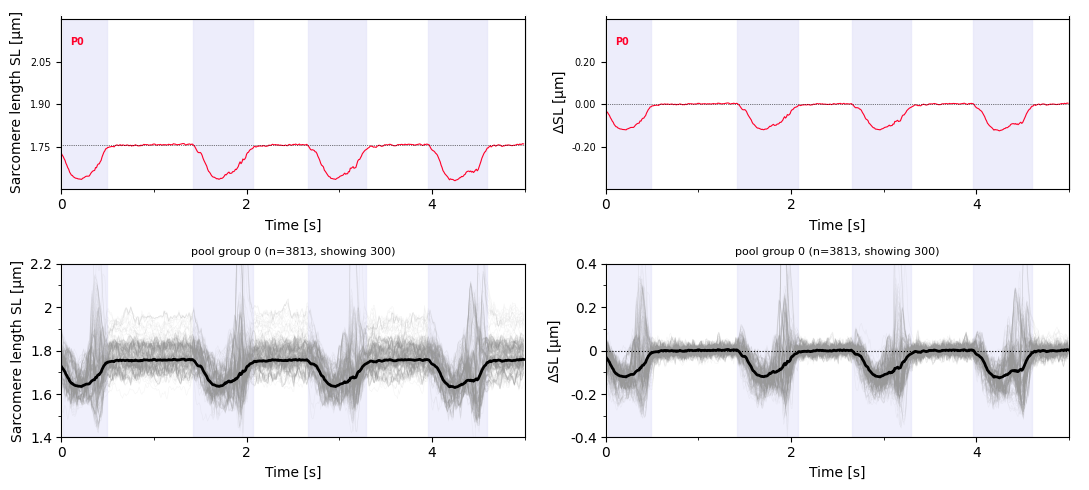

In [6]:
# pool is a single group (group=0); the identical calls work per-group for mband / domain / myofibril
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
Plots.plot_slen_mean(axes[0, 0], sarc, kind='pool', t_lim=(0, 5))            # per-group mean SL
Plots.plot_delta_slen_mean(axes[0, 1], sarc, kind='pool', t_lim=(0, 5))      # per-group mean ΔSL
Plots.plot_slen(axes[1, 0], sarc, group=0, kind='pool', t_lim=(0, 5))        # member sarcomeres + mean SL
Plots.plot_delta_slen(axes[1, 1], sarc, group=0, kind='pool', t_lim=(0, 5))  # member sarcomeres + mean ΔSL
plt.tight_layout()
plt.show()

### Inspect a grouping before you analyse it

`group_tracks` only writes label arrays (no contraction analysis), so it is cheap and freely re-callable. You can QC the partition — and see which tracks were dropped by `min_coverage` — *before* paying for the analysis. `get_tracks()` returns a tidy per-track table; `plot_track_groups` colours each track by its group.

Two knobs decide what survives: `min_coverage` drops individual tracks that snapped in too few frames, and `min_group_size` drops whole groups with too few member tracks (their group mean is too noisy to analyse). Both are also accepted by `analyze_track_motion(by=...)`.

2026-07-29 15:51:16 - sarcasm.structure - INFO - group_tracks(by='mband'): 56 groups, 3167/8678 tracks assigned.


,track_id,start_frame,length,n_frames,coverage,mean_slen,std_slen,start_y_um,start_x_um,ref_midline_id,group_id,order_in_group
0,1,0,10,500,0.020,1.761786,0.062047,0.611697,37.864029,1,-1,0
1,2,0,16,500,0.032,1.752208,0.071913,0.672866,37.864029,1,-1,0
2,3,0,22,500,0.044,1.717233,0.090723,0.734036,37.925198,1,-1,0
3,4,0,249,500,0.498,1.675504,0.075455,0.795206,37.925198,1,-1,0
4,5,0,112,500,0.224,1.661715,0.073810,0.856375,37.925198,1,-1,0


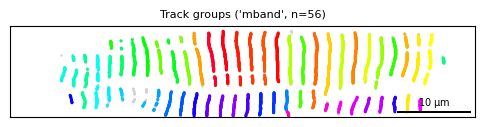

In [7]:
# group cheaply, inspect, then analyse
sarc.group_tracks(by='mband', reference_frame=0)
display(sarc.get_tracks().head())

fig, ax = plt.subplots(figsize=(6, 6))
Plots.plot_track_groups(ax, sarc, frame=0)
plt.show()

### (2) M-band level — sarcomeres sharing one M-band

Tracks that snapped to the same M-band (midline) at the reference frame form one group — the laterally-registered sarcomeres of a fibre bundle, contracting in step.

2026-07-29 15:51:20 - sarcasm.structure - INFO - group_tracks(by='mband'): 56 groups, 3167/8678 tracks assigned.
2026-07-29 15:51:22 - sarcasm.structure - INFO - analyze_track_motion: 56 'mband' groups...
2026-07-29 15:51:25 - sarcasm.analysis.contraction_analysis - INFO - 53/229 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.
2026-07-29 15:51:25 - sarcasm.structure - INFO - analyze_track_motion complete ('mband', 56 groups).


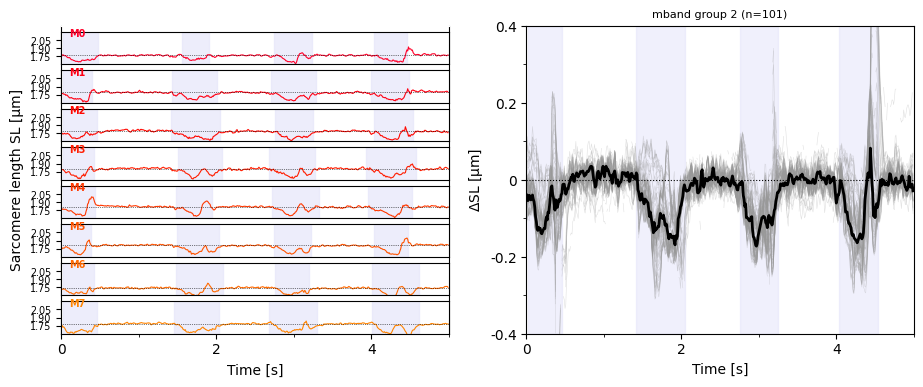

In [8]:
sarc.analyze_track_motion(by='mband', reference_frame=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
Plots.plot_slen_mean(axes[0], sarc, kind='mband', t_lim=(0, 5), n_rows=8)  # first 8 M-bands
Plots.plot_delta_slen(axes[1], sarc, group=2, kind='mband', t_lim=(0, 5))  # members of one M-band + mean
plt.show()

### (3) Myofibril level — automatic LOI-equivalent

Tracks are ordered into fibre chains from the myofibril lines (needs `analyze_myofibrils`). `analyze_track_motion(by='myofibril')` gives the per-fibre time-series, while `plot_track_myofibrils` draws each fibre as a connected polyline over the image (the spatial overlay). For the full LOI analysis, `get_track_motion(i)` returns a `Motion` view of one fibre, so **every existing LOI plot** works on a tracker-derived myofibril.

A fine grouping like this produces many 1–5 sarcomere fragments, so `min_group_size` is worth setting here: on this movie it keeps the 139 fibres with at least 6 tracked sarcomeres out of 299 raw chains.

2026-07-29 15:51:30 - sarcasm.structure - INFO - Starting myofibril line analysis...
100%|██████████| 1/1 [00:02<00:00,  2.07s/it]
2026-07-29 15:51:33 - sarcasm.structure - INFO - min_group_size=6: dropped 163 group(s) with fewer than 6 tracks.
2026-07-29 15:51:33 - sarcasm.structure - INFO - group_tracks(by='myofibril'): 134 groups, 1396/8678 tracks assigned.
2026-07-29 15:51:38 - sarcasm.structure - INFO - analyze_track_motion: 134 'myofibril' groups...
2026-07-29 15:51:54 - sarcasm.analysis.contraction_analysis - INFO - 134/538 contraction cycles are incomplete (within 3 frames of the recording start/end); they are kept in the contraction mask but their duration-dependent metrics are NaN.
2026-07-29 15:51:54 - sarcasm.structure - INFO - analyze_track_motion complete ('myofibril', 134 groups).


fibres analysed: 134


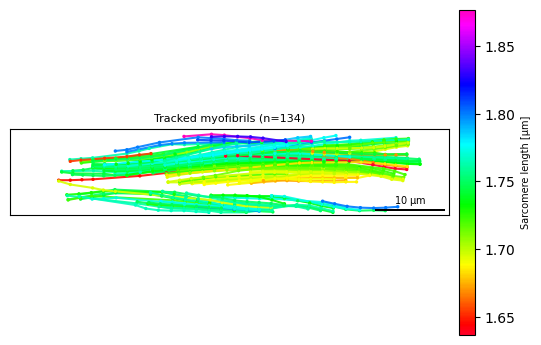

In [9]:
sarc.analyze_myofibrils(frames=[0])
# min_group_size=6 -> skip the short fibre fragments (299 raw chains -> 139 fibres)
sarc.analyze_track_motion(by='myofibril', reference_frame=0, min_group_size=6)
print('fibres analysed:', sarc.data['n_groups'])

# spatial overlay: each fibre is a polyline, coloured by its sarcomere length
fig, ax = plt.subplots(figsize=(6, 6))
Plots.plot_track_myofibrils(ax, sarc, frame=0, color_by='slen', colorbar=True)
plt.show()

2026-07-29 16:26:31 - sarcasm.utils - INFO - Using device: mps


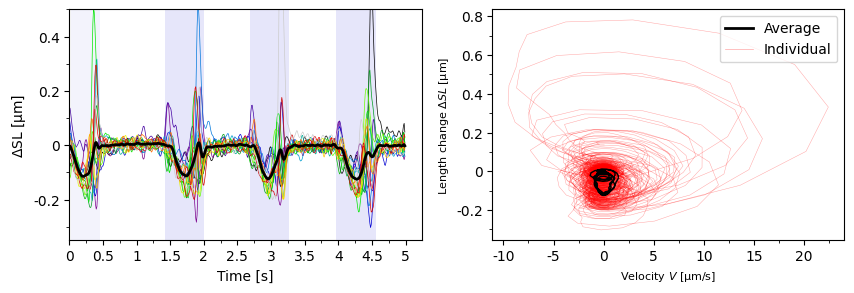

In [12]:
# rich per-fibre LOI analysis — reuse the existing Motion plots on a tracked fibre
m = sarc.get_track_motion(group=2, analyze=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
Plots.plot_overlay_delta_slen(axes[0], m)
Plots.plot_phase_space(axes[1], m)
plt.show()

### (4) LOI level — curated fibre lines (auto-detected or hand-drawn)

The **LOI** grouping is the same per-fibre engine as the myofibril method above, but instead of analysing *every* fibre it restricts to a handful of **curated lines** — handy when you care about specific fibres. `detect_lois` grows, filters and clusters candidate sarcomere lines and keeps the best `n_lois`; `group_tracks(by='loi')` then assigns each track to the nearest line and orders it along that line, so `analyze_track_motion(by='loi')` and `get_track_motion(group)` behave exactly as for `myofibril` — **every existing LOI / `Motion` plot applies**.

In the **GUI** the same grouping lives on the *Motion* tab: pick `Group by = loi` to auto-detect, or click *"Draw LOIs on movie…"* and draw the lines yourself.

In [ ]:
# analyse only a few *curated* fibre lines: the per-fibre engine of (3),
# but you pick the lines (auto-detect here, or draw them in the GUI).
sarc.detect_lois(frame=0, n_lois=4)                      # -> sarc.data['loi_data']['loi_lines']
sarc.analyze_track_motion(by='loi', reference_frame=0)   # group tracks along each LOI, then analyse

# tracks-as-lines, coloured by their LOI group (trajectory view)
fig, ax = plt.subplots(figsize=(6, 6))
Plots.plot_tracks(ax, sarc, color_by='group')
plt.show()


2026-07-29 17:11:34 - sarcasm.utils - INFO - Using device: mps


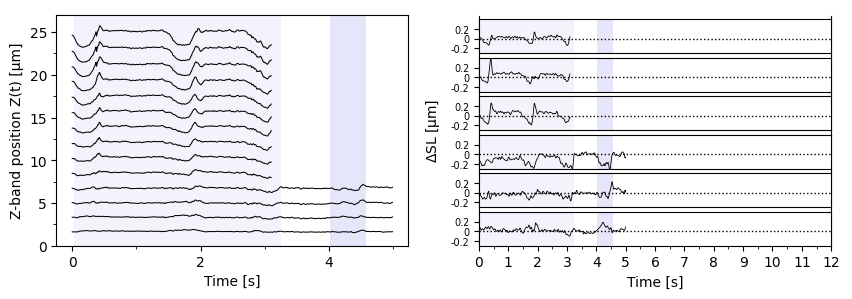

In [7]:

# rich per-LOI analysis — every existing LOI / Motion plot works on one curated line
m = sarc.get_track_motion(group=3, analyze=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
Plots.plot_z_pos(axes[0], m)
Plots.plot_delta_slen(axes[1], m)
plt.show()

### (5) Domain level — replaces the former `analyze_domain_motion`

The domain method clusters tracks into Leiden domains and writes the **same `domain_*` keys** as the old static-mask analysis, so the existing domain plots keep working unchanged. (This replaces the former `analyze_domain_motion`, which has been removed — use `analyze_track_motion(by='domain')`.)

In [ ]:
sarc.analyze_sarcomere_domains(frames=[0])
sarc.analyze_track_motion(by='domain', reference_frame=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
Plots.plot_sarcomere_domains(axes[0], sarc, frame=0)        # unchanged legacy plot
Plots.plot_domain_timeseries(axes[1], sarc, t_lim=(0, 2))   # unchanged legacy plot
plt.show()

### (6) Custom grouping

Supply your own integer label per track (row-aligned to `track_ids`) — e.g. from an external segmentation, a region mask, or well metadata. No new code path: `pool`/`domain`/… all run through the same engine.

In [ ]:
# example: split tracks into short vs long sarcomeres
tracks = sarc.get_tracks()
labels = (tracks['mean_slen'] > tracks['mean_slen'].median()).astype(int).values
sarc.group_tracks(by='custom', labels=labels)
sarc.analyze_track_motion()
print('n custom groups:', sarc.data['n_groups'])

## Inspect results
Outputs live in `sarc.data`: `tracks_slen`, `tracks_positions_um`, `tracks_positions_px`, `tracks_orientations`, `tracks_snapped`, and the motion-field decomposition (`displacement_along_sarcomere`, `displacement_perpendicular`, `velocity_magnitude`).

In [6]:
slen = np.asarray(sarc.data['tracks_slen'])           # (n_tracks, T)
pos = np.asarray(sarc.data['tracks_positions_um'])     # (n_tracks, T, 2)
snapped = np.asarray(sarc.data['tracks_snapped']).astype(bool)
T = slen.shape[1]
time_s = np.arange(T) * sarc.metadata.frametime
cov = snapped.sum(axis=1) / T
print(f"{slen.shape[0]} tracks; {(cov >= 0.8).sum()} with ≥80% coverage")

6350 tracks; 3138 with ≥80% coverage


### Ensemble sarcomere length

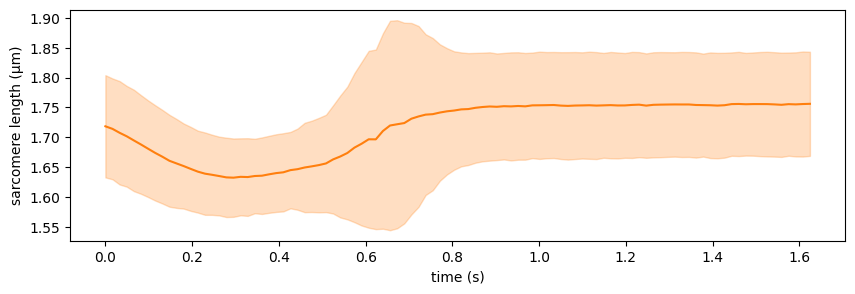

In [7]:
ok = cov >= 0.8
mean = np.nanmean(slen[ok], axis=0)
std = np.nanstd(slen[ok], axis=0)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s, mean, color='C1')
ax.fill_between(time_s, mean - std, mean + std, alpha=0.25, color='C1')
ax.set_xlabel('time (s)'); ax.set_ylabel('sarcomere length (µm)')
plt.show()

### Sample individual trajectories

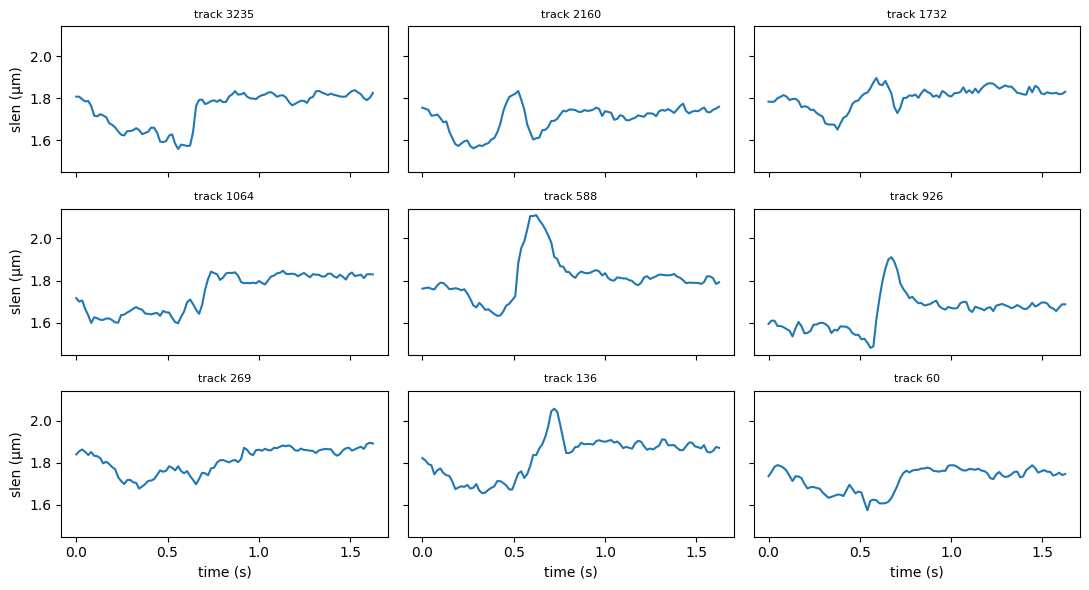

In [8]:
rng = np.random.default_rng(0)
picks = rng.choice(np.where(cov >= 0.95)[0], 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(11, 6), sharex=True, sharey=True)
for ax, i in zip(axes.flat, picks):
    ax.plot(time_s, slen[i])
    ax.set_title(f'track {int(sarc.data["track_ids"][i])}', fontsize=8)
for ax in axes[-1]: ax.set_xlabel('time (s)')
for ax in axes[:, 0]: ax.set_ylabel('slen (µm)')
plt.tight_layout(); plt.show()

### Displacement from origin

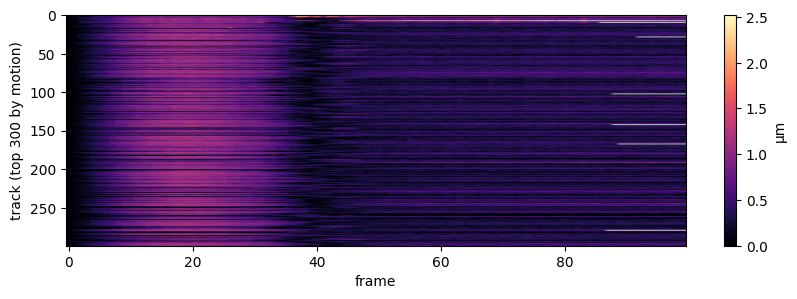

In [9]:
disp = np.linalg.norm(pos - pos[:, :1, :], axis=-1)  # (n_tracks, T)
top = np.argsort(-np.nansum(np.abs(np.diff(disp, axis=1)), axis=1))[:300]
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(disp[top], aspect='auto', cmap='magma')
ax.set_xlabel('frame'); ax.set_ylabel('track (top 300 by motion)')
fig.colorbar(im, ax=ax, label='µm')
plt.show()

## Motion field without tracking
`SarcAsM.compute_motion_field` computes the flow + per-frame along/perp decomposition only (no tracking). Same `displacement_*` / `velocity_magnitude` outputs as the tracker.

In [10]:
# sarc.compute_motion_field(frames=frames)

## See also
* [`tutorial_structure_analysis.ipynb`](tutorial_structure_analysis.ipynb) — upstream detection
* [`docs/development_sarcomere_tracking.md`](../development_sarcomere_tracking.md) — algorithm details